# Redes Bayesianas

## Introducción

Una aproximación intuitiva al razonamiento con incertidumbre se encuentra en la **teoría de la probabilidad**. Al necesitar modelar hechos que no sean categórico, la función de probabilidad parece una buena candidata para representar este comportamiento.

Usando esta idea como base, las **redes bayesianas** se presentan como el principal ejemplo de esta aproximación, modelando los hechos como probabilidades y las relaciones entre ellos como probabilidades condicionales.

## Modelo

### Repaso de probabilidades condicionales

* **Probabilidad marginal**: describe la probabilidad de un evento aislado $$P(A)$$
  * Ejemplo:
    $P(A) = 0.3$
  * Interpretación:
    *"Sin información adicional, ¿cómo de probable es que se dé el evento A?"*
* **Probabilidad conjunta**: describe la probabilidad de que ocurran dos eventos simultáneamente $$P(A,B)$$
  * Ejemplo:
    $P(A, B) = P(A)P(B)$ (si y sólo si son independientes)
  * Interpretación:
    *"¿Cómo de probable es que ambos eventos se den a la vez?"*
* **Probabilidad condicional**: describe cómo cambia la probabilidad al conocer nueva información $$P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}$$
  * Interpretación:
    *"Reducimos el espacio muestral a los casos donde ocurre B, y dentro de ese subconjunto, medimos A."*
* **Regla del producto**: describe la probabilidad de que ocurran dos eventos dependientes $$P(A,B) = P(A \mid B)P(B) = P(B \mid A)P(A)$$
  * Interpretación:
    *"¿Cómo de probable es que ambos eventos dependientes se den a la vez?"*
* **Regla de Bayes**: describe las probabilidades *a priori* y *a posteriori* de las variables dependientes $$P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}$$
  * Interpretación:
    *"¿Cómo de probable es una evidencia teniendo en cuenta la consecuencia?"*

#### Ejercicios - Parte 1

Completa las siguientes funciones en Python para implementar las reglas probabilísitcas previas.

In [ ]:
# =====================================
# 1. Probabilidad marginal
# =====================================

"""
Ejercicio 1:
En una población, el 30% fuma.
"""

p_fumar = 0.3

# TODO:
p_no_fumar = None

print("P(Fumar)=", p_fumar)
print("P(No fumar)=", p_no_fumar)

# =====================================
# 2. Probabilidad conjunta
# =====================================

"""
Ejercicio 2:
P(Fumar)=0.3
P(Cáncer | Fumar)=0.1
"""

p_fumar = 0.3
p_cancer_dado_fumar = 0.1

# TODO:
p_fumar_y_cancer = None

print("P(Fumar, Cancer)=", p_fumar_y_cancer)

# =====================================
# 3. Probabilidad condicional inversa
# =====================================

"""
Ejercicio 3:
Calcular P(Fumar | Cáncer)
"""

p_fumar = 0.3
p_cancer = 0.05
p_cancer_dado_fumar = 0.1

# Paso 1
p_fumar_y_cancer = None

# Paso 2
p_fumar_dado_cancer = None

print("P(Fumar | Cancer)=", p_fumar_dado_cancer)

# =====================================
# 4. Regla de Bayes (test médico)
# =====================================

p_enfermedad = 0.01
p_test_pos_dado_enf = 0.95
p_test_pos_dado_no_enf = 0.05

# Paso 1: P(Test+)
p_test_pos = None

# Paso 2: Bayes
p_enf_dado_test = None

print("P(Enfermedad | Test+)=", p_enf_dado_test)



### Definición de redes

Una red bayesiana es un **modelo gráfico probabilístico** que representa un conjunto de variables y sus probabilidades condicionales mediante un grafo dirigido acíclico.

Por ejemplo: 

> Queremos modelar las dependencias entre tres variables: el aspersor (o, más concretamente, su estado: si está encendido o no), la presencia o ausencia de lluvia y si el césped está mojado o no. Hay dos factores que pueden hacer que el césped se moje: un aspersor en funcionamiento o la lluvia. La lluvia tiene un efecto directo sobre el uso del aspersor (es decir, cuando llueve, el aspersor no suele estar en funcionamiento).

Con esta definición, se obtiene un grafo como el siguiente:

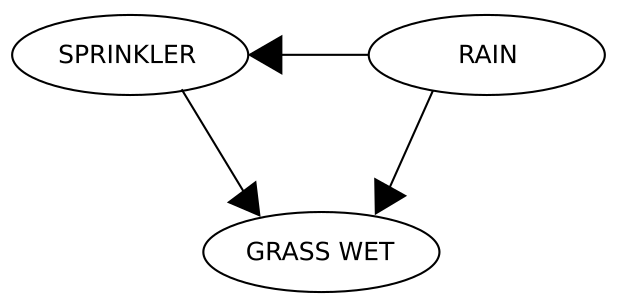


Dado que cada variable tiene dos posibles estados (True y False), se generan las siguientes **tablas de probabilidad condicional (CPTs)**:

<table class="tg"><thead>
  <tr>
    <th class="tg-0pky" colspan="2">Lluvia</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-0pky">T</td>
    <td class="tg-0pky">F</td>
  </tr>
  <tr>
    <td class="tg-0pky">0.2</td>
    <td class="tg-0pky">0.8</td>
  </tr>
</tbody>
</table>
<br>
<table><thead>
  <tr>
    <th colspan="2" rowspan="2"></th>
    <th colspan="2">Aspersor</th>
  </tr>
  <tr>
    <th>T</th>
    <th>F</th>
  </tr></thead>
<tbody>
  <tr>
    <td rowspan="2">Lluvia</td>
    <td>F</td>
    <td>0.4</td>
    <td>0.6</td>
  </tr>
  <tr>
    <td>T</td>
    <td>0.01</td>
    <td>0.99</td>
  </tr>
</tbody>
</table>
<br>
<table><thead>
  <tr>
    <th colspan="2"></th>
    <th colspan="2">H. mojada</th>
  </tr></thead>
<tbody>
  <tr>
    <td>Aspersor</td>
    <td>Lluvia</td>
    <td>T</td>
    <td>F</td>
  </tr>
  <tr>
    <td>F</td>
    <td>F</td>
    <td>0</td>
    <td>1</td>
  </tr>
  <tr>
    <td>F</td>
    <td>T</td>
    <td>0.8</td>
    <td>0.2</td>
  </tr>
  <tr>
    <td>T</td>
    <td>F</td>
    <td>0.9</td>
    <td>0.1</td>
  </tr>
  <tr>
    <td>T</td>
    <td>T</td>
    <td>0.99</td>
    <td>0.01</td>
  </tr>
</tbody>
</table>

A partir de estos datos, se puede aplicar la **función de probabilidad conjunta**, que para este problema queda definida como:

$$P(G,S,R) = P(G \mid S,R)P(S \mid R)P(R)$$

Este constructo nos permite realizar preguntas sobre el modelo. Por ejemplo:

> ¿Cuál es la probabilidad de que haya llovido, teniendo en cuenta que la hierba está mojada?

Se modela como:

$$P(R = T \mid G = T) = \frac{P(G = T, R = T)}{P(G = T)} = \frac{\sum_{x \in \{T,F\}}P(G = T, S = x, R = T)}{\sum_{x,y \in \{T,F\}}P(G = T, S = x, R = y)}$$

Haciendo uso de la función de probabilidad conjunta, se obtienen cada uno de los términos de la ecuación, por ejemplo:

$$
\begin{align*}
P(G = T, S = T, R = T) &= P(G = T \mid S=T,R=T)P(S=T \mid R=T)P(R=T) \\
                       &= 0.99 \times 0.01 \times 0.2 \\
                       &= 0.00198
\end{align*}
$$

Aplicando el mismo procedimiento para cada uno de los términos se obtiene que:

$$P(R = T \mid G = T) = \frac{0.00198_{TTT} + 0.1584_{TFT}}{0.00198_{TTT} + 0.288_{TTF} + 0.1584_{TFT} + 0.0_{TFF}} \approx 35.77\%$$

#### Ejercicios - Parte 2

Modela el problema de la hierba mojada siguiendo los pasos a continuación. Puedes usar las funciones definidas en la Parte 1.

In [ ]:
# =====================================
# Ejercicio: Red Bayesiana - Hierba Mojada
# =====================================

"""
Variables:
- Rain (R): llueve
- Sprinkler (S): aspersor encendido
- WetGrass (W): hierba mojada

Estructura:
Rain → Sprinkler
Rain → WetGrass
Sprinkler → WetGrass

Objetivo:
1. Definir las probabilidades
2. Implementar la probabilidad conjunta
3. Calcular P(WetGrass = True)
"""

# =====================================
# 1. Definir probabilidades
# =====================================

# Probabilidades marginales
P_R = 0.2            # P(Rain=True)
P_S = 0.5            # P(Sprinkler=True)

# Probabilidades condicionales 
# P(S | R)
P_S = {
    False: 0.4, # P(Sprinkler | Rain = False)
    True: 0.01, # P(Sprinkler | Rain = True)
}

# P(W | S, R)
P_W = {
    (False, False): 0.0, # P(WetGrass | Sprinkler = False, Rain = False)
    (False, True): 0.8,  # P(WetGrass | Sprinkler = False, Rain = True)
    (True, False): 0.9,  # P(WetGrass | Sprinkler = True, Rain = False)
    (True, True): 0.99,  # P(WetGrass | Sprinkler = True, Rain = True)
}

# =====================================
# 2. Función de probabilidad conjunta
# =====================================

def prob_conjunta(r, s, w):
    """
    Calcula P(R=r, S=s, W=w)
    
    r, s, w: booleanos
    """
    # TODO:
    # 1. Calcular P(R=r)
    # 2. Calcular P(S=s)
    # 3. Calcular P(W=w | r,s)
    # 4. Multiplicar todo
    
    pass

# =====================================
# 3. Calcular P(WetGrass=True)
# =====================================

def prob_wetgrass_true():
    """
    Sumar sobre todas las combinaciones de R y S
    """
    total = 0
    
    # TODO:
    # recorrer r ∈ {True, False}
    # recorrer s ∈ {True, False}
    # sumar P(r,s,W=True)
    
    return total

# =====================================
# 4. BONUS: Inferencia inversa
# =====================================

def prob_rain_given_wetgrass():
    """
    Calcular P(Rain=True | WetGrass=True)
    usando:
    P(R|W) = P(R,W) / P(W)
    """
    # TODO:
    # 1. calcular P(R=True, W=True)
    # 2. dividir por P(W=True)
    
    pass

# =====================================
# Pruebas (no modificar)
# =====================================

print("P(W=True) =", prob_wetgrass_true())
print("P(R=True | W=True) =", prob_rain_given_wetgrass())